In [101]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import detrend

In [67]:
%matplotlib inline

In [80]:
# path = '/work3/viswa/results/results_prev/mrr_sac_cluster_delayed_toptica_pow_ton_un_norm_high_only_detuning_v8/high/new_ctrl_freq/30_16__acav_history.npy'
# path = '/work3/viswa/results/results_prev/mrr_sac_cluster_delayed_toptica_pow_ton_un_norm_high_only_detuning_v8/high/normal/50_16__acav_history.npy'
# path = '/work3/viswa/results/results_prev/mrr_sac_cluster_delayed_toptica_pow_ton_un_norm_high_only_detuning_v8/high/phase_noise/10_16__acav_history.npy'
# path = '/work3/viswa/results/results_prev/mrr_sac_cluster_delayed_toptica_pow_ton_un_norm_high_only_detuning_v8/high/normal_no_shot_noise/40_16__acav_history.npy'
# path = '/work3/viswa/results/results_prev/mrr_sac_cluster_delayed_toptica_pow_ton_un_norm_high_only_detuning_v8/high/phase_noise_raman_ctrl/70_16__acav_history.npy'
# path = '/work3/viswa/results/mrr_sac_cluster_delayed_toptica_pow_ton_un_norm_high_only_detuning_v8/high/phase_noise_to_shot/00_16__acav_history.npy'
# path = '/work3/viswa/results/mrr_sac_cluster_delayed_toptica_pow_ton_un_norm_high_only_detuning_v8/high/phase_noise_to_shot/30_16__acav_history.npy'
# path = '/work3/viswa/results/mrr_sac_cluster_delayed_toptica_pow_ton_un_norm_high_only_detuning_v8/high/new_ctrl_freq/noise_to_shot/10_16__acav_history.npy'
path = '/work3/viswa/results/mrr_sac_cluster_delayed_toptica_pow_ton_un_norm_high_only_detuning_v8/high/new_ctrl_freq/phase_noise_to_shot_raman_2x_delay/10_16__acav_history.npy'
acav_history_8 = np.load(path).T
acav_history_8.shape

(441, 9900)

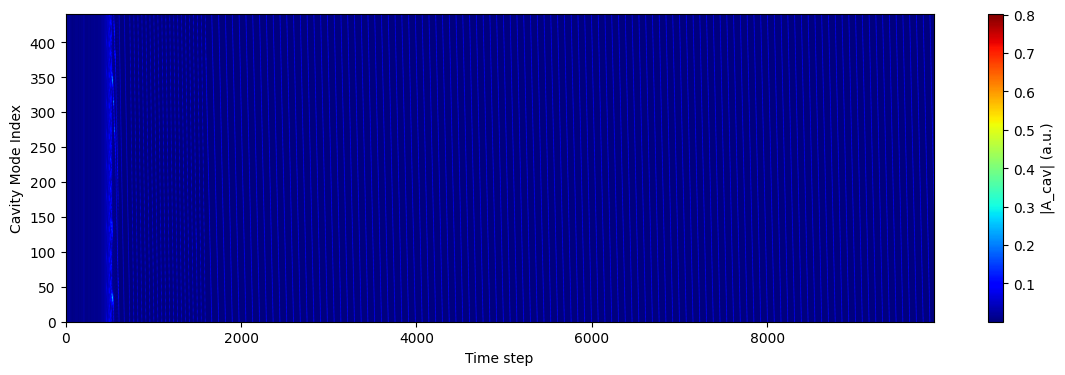

In [81]:
plt.figure(figsize=(14, 4))
plt.imshow(1e3*np.abs(acav_history_8)**2, aspect='auto', extent=[0, acav_history_8.shape[1], 0, acav_history_8.shape[0]], cmap='jet')
# plt.axvline(4500, color='red', linestyle='--')
plt.colorbar(label='|A_cav| (a.u.)')
plt.xlabel('Time step')
plt.ylabel('Cavity Mode Index')
plt.show()

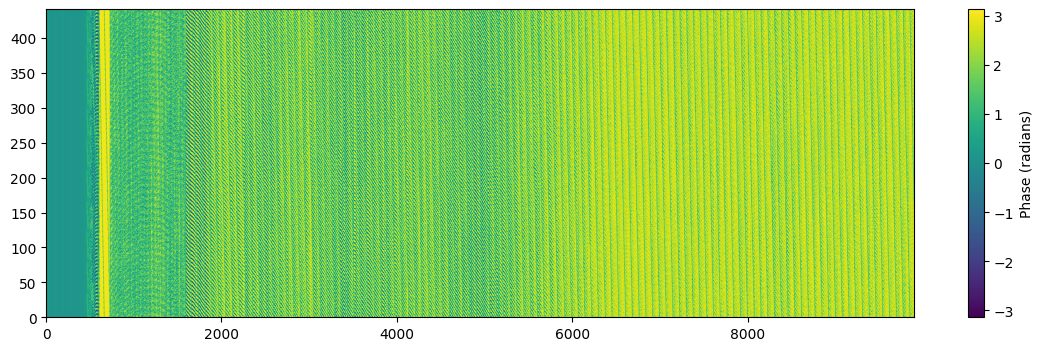

In [82]:
# plot phase of acav_history_8
plt.figure(figsize=(14, 4))
plt.imshow(np.angle(acav_history_8), aspect='auto', extent=[0, acav_history_8.shape[1], 0, acav_history_8.shape[0]])
# plt.axvline(4500, color='red', linestyle='--')
plt.colorbar(label='Phase (radians)')
# plt.xlim(4500,7500)
plt.show()

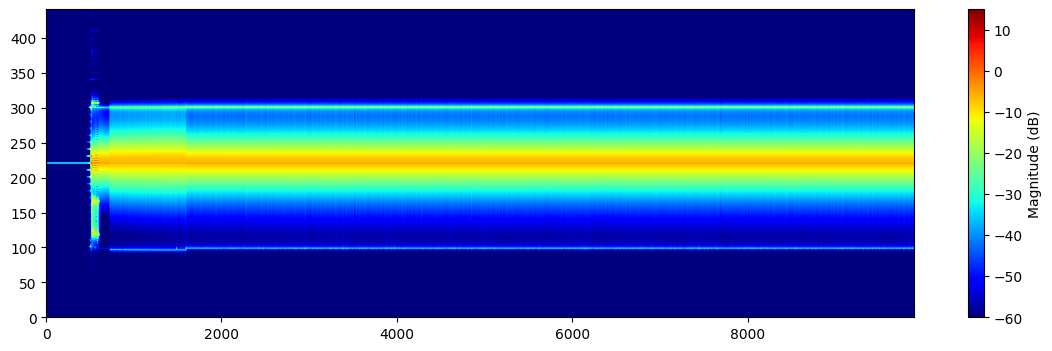

In [83]:
# compute fourier transform along mode axis
acav_fft_8 = np.fft.fftshift(np.fft.fft(acav_history_8, axis=0), axes=0)/np.sqrt(441)
acav_fft_8_mag = np.abs(acav_fft_8)**2
# convert to dB scale
acav_fft_8_mag = 10 * np.log10(acav_fft_8_mag + 1e-12)  + 30# add small value to avoid log(0) 
acav_fft_8_mag = np.clip(acav_fft_8_mag, a_min=-60, a_max=50)
plt.figure(figsize=(14, 4))
plt.imshow(acav_fft_8_mag, aspect='auto', extent=[0, acav_fft_8_mag.shape[1], 0, acav_fft_8_mag.shape[0]], cmap='jet')
plt.colorbar(label='Magnitude (dB)')
# plt.axvline(1200, color='red', linestyle='--')
plt.show()

In [72]:
# plt.figure(figsize=(14,4))
# plt.plot(acav_fft_8_mag [:, 3000])
# plt.xlim(125,345)
# plt.show()

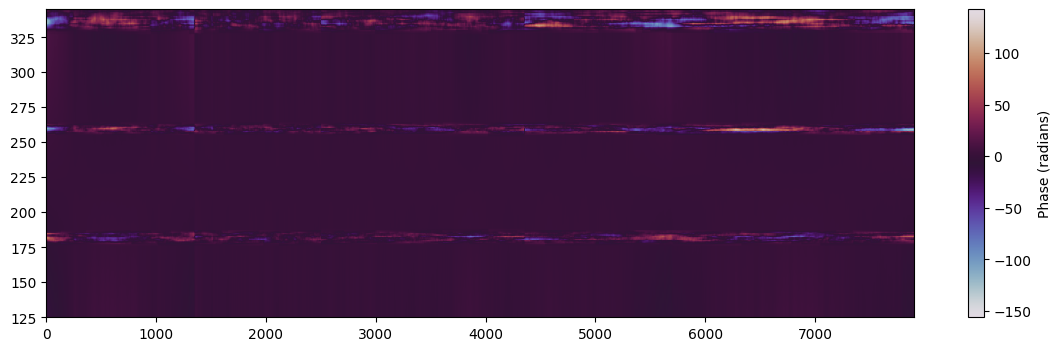

In [90]:
# plot the phase of the fft 
acav_fft_8_phase = np.angle(acav_fft_8)[:, 2000:]
# unwrap the phase along time axis
acav_fft_8_phase = np.unwrap(acav_fft_8_phase, axis=1)
# detrend the phase along time axis
acav_fft_8_phase = detrend(acav_fft_8_phase, axis=1, bp=[1350,2500,4350])
# acav_fft_8_phase = detrend(acav_fft_8_phase, axis=1)
plt.figure(figsize=(14, 4))
plt.imshow(acav_fft_8_phase, aspect='auto', extent=[0, acav_fft_8_phase.shape[1], 0, acav_fft_8_phase.shape[0]], cmap='twilight')
# plt.axvline(4500, color='red', linestyle='--')
plt.colorbar(label='Phase (radians)')
plt.ylim(125,345)
plt.show()

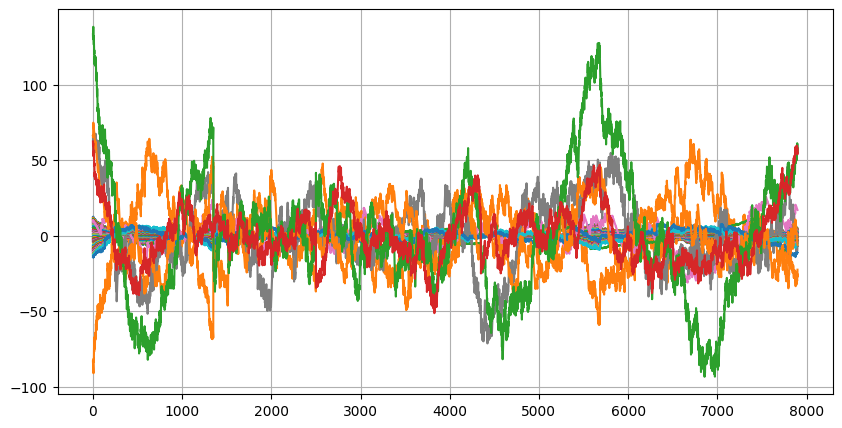

In [91]:
# detrend and plot the first mode phase
# %matplotlib widget
idx_mode = 2
plt.figure(figsize=(10,5))
for idx_mode in range(125, 345, 5):
    detrend_phase = acav_fft_8_phase[idx_mode] 
    plt.plot(detrend_phase, label=f'Mode {idx_mode}')
    # plt.legend()
plt.grid()
# plt.axvline(4500, color='red', linestyle='--')
# plt.xlim(2500,10000)
# plt.ylim(-100,100)
plt.show()
# plt.plot(acav_fft_8_phase[0])
# %matplotlib inline

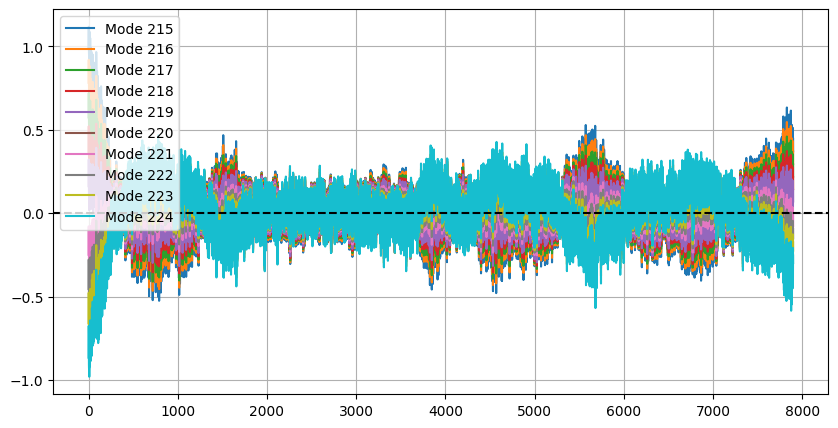

In [92]:
# plot the jitter of phase of all comb lines w.r.t central line (mode 220)
acav_fft_8_phase = np.angle(acav_fft_8)[:, 2000:]
acav_fft_8_phase = np.unwrap(acav_fft_8_phase, axis=1)
# detrend the phase along time axis
acav_fft_8_phase = detrend(acav_fft_8_phase, axis=1)
central_mode_phase = acav_fft_8_phase[220]
plt.figure(figsize=(10,5))
for idx_mode in range(220-5,220+5):
    phase_jitter = acav_fft_8_phase[idx_mode] - central_mode_phase
    plt.plot(phase_jitter, label=f'Mode {idx_mode}')
    # plt.legend()
plt.grid()
plt.axhline(0, color='black', ls='--')
# plt.axvline(4500, color='red', linestyle='--')
plt.legend()
# plt.xlim(2200,20000)
# plt.ylim(-5,5)
plt.show()


In [76]:
"""
Power Spectral Density Calculator
Computes field PSD and phase noise (SSB and DSB)
"""

import numpy as np
from scipy.signal.windows import hann


class PowerSpectralDensity:
    """Power spectral density calculator"""
    
    def __init__(self, Fs):
        """
        Initialize PSD calculator
        
        Parameters:
        -----------
        Fs : float
            Sampling frequency (Hz)
        """
        self.Fs = Fs
    
    def field_psd(self, X, shift=True):
        """
        Compute power spectral density of field
        
        Parameters:
        -----------
        X : array_like
            Input field signal (can be complex)
        shift : bool, optional
            Shift zero frequency to center (default: True)
            
        Returns:
        --------
        freq : ndarray
            Frequency axis (Hz)
        PSD : ndarray
            Power spectral density
        """
        X = np.asarray(X).flatten()
        L = len(X)
        
        if shift:
            PSD = np.abs(np.fft.fftshift(np.fft.fft(X) / L)) ** 2
            freq = np.fft.fftshift(np.fft.fftfreq(L, 1/self.Fs))
        else:
            PSD = np.abs(np.fft.fft(X) / L) ** 2
            freq = np.fft.fftfreq(L, 1/self.Fs)[:L]
            
        return freq, PSD
    
    def phase_noise_dsb(self, X):
        """
        Compute double-sideband (DSB) phase noise PSD
        
        Parameters:
        -----------
        X : array_like
            Phase noise signal (rad)
            
        Returns:
        --------
        freq : ndarray
            Frequency axis (Hz), range [0, Fs)
        PSD_phase_noise : ndarray
            DSB phase noise PSD (rad²/Hz)
        """
        X = np.asarray(X).flatten()
        X = X - np.mean(X)
        L = len(X)
        
        W = hann(L)
        U = np.sum(W ** 2)
        
        X_windowed = X * W
        X_fft = np.fft.fft(X_windowed)
        
        PSD_phase_noise = (1 / (self.Fs * U)) * np.abs(X_fft) ** 2
        freq = np.arange(L) * self.Fs / L
        
        return freq, PSD_phase_noise
    
    def phase_noise_ssb(self, X):
        """
        Compute single-sideband (SSB) phase noise PSD
        
        Parameters:
        -----------
        X : array_like
            Phase noise signal (rad)
            
        Returns:
        --------
        freq : ndarray
            Frequency axis (Hz), range [0, Fs/2]
        PSD_phase_noise : ndarray
            SSB phase noise PSD (rad²/Hz)
        """
        X = np.asarray(X).flatten()
        X = X - np.mean(X)
        L = len(X)
        
        W = hann(L)
        U = np.sum(W ** 2)
        
        X_windowed = X * W
        X_fft = np.fft.fft(X_windowed)
        
        PSD_2s = (1 / (self.Fs * U)) * np.abs(X_fft) ** 2
        
        if L % 2 == 0:
            half_n = L // 2 + 1
            PSD_1s = PSD_2s[:half_n].copy()
            PSD_1s[1:half_n-1] *= 2
        else:
            half_n = (L + 1) // 2
            PSD_1s = PSD_2s[:half_n].copy()
            PSD_1s[1:half_n] *= 2
        
        freq = np.arange(half_n) * (self.Fs / L)
        
        return freq, PSD_1s
    
    def frequency_noise_ssb(self, X):
        """
        Compute SSB frequency noise PSD
        S_nu(f) = f^2 * S_phi(f)
        
        Parameters:
        -----------
        X : array_like
            Phase noise signal (rad)
            
        Returns:
        --------
        freq : ndarray
            Frequency axis (Hz)
        PSD_freq_noise : ndarray
            Frequency noise PSD (Hz²/Hz)
        """
        freq, PSD_phase_noise = self.phase_noise_ssb(X)
        PSD_freq_noise = (freq ** 2) * PSD_phase_noise
        
        return freq, PSD_freq_noise

In [77]:
# %matplotlib inline

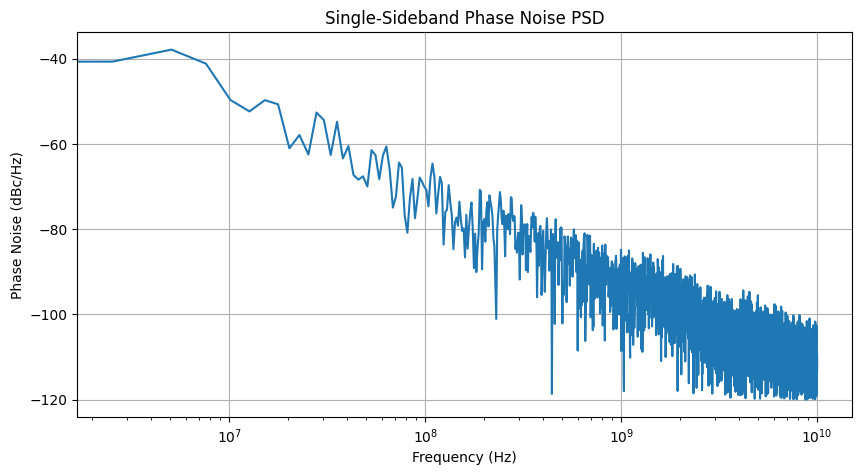

In [93]:
# find field psd
phase_noise_analyzer = PowerSpectralDensity(Fs=20e9)  # Example: 10 GHz sampling frequency
freq, phase_noise = phase_noise_analyzer.phase_noise_ssb(acav_fft_8_phase[0])
plt.figure(figsize=(10,5))
plt.semilogx(freq, 10 * np.log10(phase_noise + 1e-12))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Phase Noise (dBc/Hz)')
plt.title('Single-Sideband Phase Noise PSD')
plt.grid()
plt.show()

Individual Comb Line Linewidths
Mode Index   Rel. Index   Linewidth (kHz)     
------------------------------------------------------------
        200         -20          2100.73
        201         -19          1896.07
        202         -18          1701.93
        203         -17          1518.29
        204         -16          1345.16
        205         -15          1182.54
        206         -14          1030.43
        207         -13           888.88
        208         -12           757.82
        209         -11           637.22
        210         -10           526.99
        211          -9           427.69
        212          -8           338.69
        213          -7           260.23
        214          -6           192.27
        215          -5           134.82
        216          -4            87.91
        217          -3            51.54
        218          -2            25.72
        219          -1            10.41
        220           0             5.06

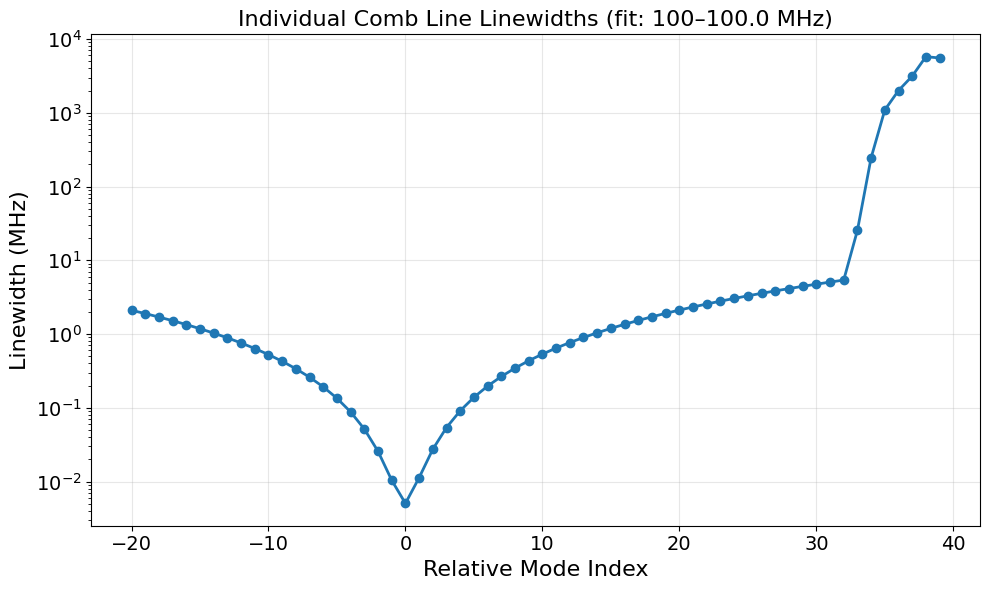


Linewidth Statistics:
  Mean: 298075.54 kHz
  Std:  1108203.44 kHz
  Min:  5.06 kHz (Mode 220)
  Max:  5765021.30 kHz (Mode 258)


In [97]:
import numpy as np
import matplotlib.pyplot as plt

# ---- choose which phase-matrix to use (modes x time) ----
# If you want the same slice you used earlier:
mode_start, mode_stop = 200,260          # FFT-mode indices to analyze
t_start = 2000                            # time index to start from (steady-state)
phi_mat = np.angle(acav_fft_8)[mode_start:mode_stop, t_start:]
phi_mat = np.unwrap(phi_mat, axis=1)
phi_mat = detrend(phi_mat, axis=1)        # remove linear drift

Nc = phi_mat.shape[0]
mode_indices = np.arange(mode_start, mode_stop)  # absolute indices
mode_indices_rel = mode_indices - 220#mode_indices[Nc // 2]

# ---- PSD settings ----
dt = 100e-12
Fs = 1.0 / dt
phase_noise_analyzer = PowerSpectralDensity(Fs=Fs)

# ---- compute SSB phase-noise PSD for each comb line: Sphi(f) [rad^2/Hz] ----
freq, Sphi0 = phase_noise_analyzer.phase_noise_ssb(phi_mat[0])
PhaseNoiseMat = np.full((len(freq), Nc), np.nan)
PhaseNoiseMat[:, 0] = Sphi0

for i in range(1, Nc):
    f_i, Sphi_i = phase_noise_analyzer.phase_noise_ssb(phi_mat[i])
    # assume same freq grid; if not, you should interpolate
    PhaseNoiseMat[:, i] = Sphi_i

# ---- linewidth fit band (offset frequency) ----
f1_fit = 1e5   # 100 kHz
f2_fit = 100e6   # 1 MHz
idx_fit = (freq >= f1_fit) & (freq <= f2_fit)

# ---- linewidth per comb line ----
# Using: Δν ≈ π * < f^2 * Sphi(f) > over the fit band
DeltaNu_each = np.full(Nc, np.nan)  # Hz

for i in range(Nc):
    Sphi_i = PhaseNoiseMat[:, i]
    valid = idx_fit & np.isfinite(Sphi_i) & (Sphi_i > 0)
    if np.sum(valid) >= 10:
        DeltaNu_each[i] = np.mean(np.pi * (freq[valid] ** 2) * Sphi_i[valid])

# ---- print table ----
print("Individual Comb Line Linewidths")
print("=" * 60)
print(f"{'Mode Index':<12} {'Rel. Index':<12} {'Linewidth (kHz)':<20}")
print("-" * 60)
for i in range(Nc):
    if np.isfinite(DeltaNu_each[i]):
        print(f"{mode_indices[i]:>11}  {mode_indices_rel[i]:>10}  {DeltaNu_each[i]/1e3:>15.2f}")
print("=" * 60)

# ---- plot linewidths ----
valid_mask = np.isfinite(DeltaNu_each)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(mode_indices_rel[valid_mask], DeltaNu_each[valid_mask] / 1e6, "o-",
        linewidth=2, markersize=6)
ax.set_xlabel("Relative Mode Index", fontsize=16)
ax.set_ylabel("Linewidth (MHz)", fontsize=16)
ax.set_title(f"Individual Comb Line Linewidths (fit: {f1_fit/1e3:.0f}–{f2_fit/1e6:.1f} MHz)", fontsize=16)
ax.grid(True, alpha=0.3)
# set yscale to log
ax.set_yscale('log')
# set tick size to 14
ax.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

# ---- summary statistics ----
if np.any(valid_mask):
    i_min = np.nanargmin(DeltaNu_each)
    i_max = np.nanargmax(DeltaNu_each)
    print("\nLinewidth Statistics:")
    print(f"  Mean: {np.nanmean(DeltaNu_each)/1e3:.2f} kHz")
    print(f"  Std:  {np.nanstd(DeltaNu_each)/1e3:.2f} kHz")
    print(f"  Min:  {DeltaNu_each[i_min]/1e3:.2f} kHz (Mode {mode_indices[i_min]})")
    print(f"  Max:  {DeltaNu_each[i_max]/1e3:.2f} kHz (Mode {mode_indices[i_max]})")
else:
    print("\nNo valid linewidths computed (check fit band and PSD positivity).")

In [98]:
from scipy.optimize import curve_fit

# 1. Define the parabolic model
def parabola(n, A, B, C):
    return A + B*n + C*n**2

# 2. Fit the data (using relative mode indices and linewidths in Hz)
# Ensure we use valid_mask from your previous code
n_rel = mode_indices_rel[valid_mask]
l_widths = DeltaNu_each[valid_mask]

popt, pcov = curve_fit(parabola, n_rel, l_widths)
A_fit, B_fit, C_fit = popt

# 3. Calculate Timing Jitter
# C_fit is the contribution per mode squared (Hz)
# The RMS timing jitter over an observation time T can be derived from C
f_rep = 1 / dt  # Round-trip frequency
# Simple estimate of the Repetition Rate Linewidth:
delta_nu_rep = C_fit 

print(f"\n--- Jitter Analysis ---")
print(f"Pump Contribution (A): {A_fit/1e3:.2f} kHz")
print(f"Rep. Rate Linewidth contribution (C): {C_fit:.2f} Hz/mode^2")

# Timing jitter (approximate cycle-to-cycle jitter)
# sigma_t = sqrt(delta_nu_rep / (2 * pi * f_rep^3)) 
jitter_fs = 1e15 * np.sqrt(delta_nu_rep / (2 * np.pi * f_rep**3))
print(f"Estimated cycle-to-cycle Timing Jitter: {jitter_fs:.4f} fs")


--- Jitter Analysis ---
Pump Contribution (A): -395449.61 kHz
Rep. Rate Linewidth contribution (C): 2043557.64 Hz/mode^2
Estimated cycle-to-cycle Timing Jitter: 570.3002 fs


In [ ]:
FSR = 982262981718.388
fpmp = 282645887847461.94
freq = (fpmp + np.arange(-220,221)*FSR)
freq_valid = freq[mode_indices_rel[valid_mask] + 220]
mag_valid = acav_fft_8_mag[mode_indices_rel[valid_mask] + 220, 6000]

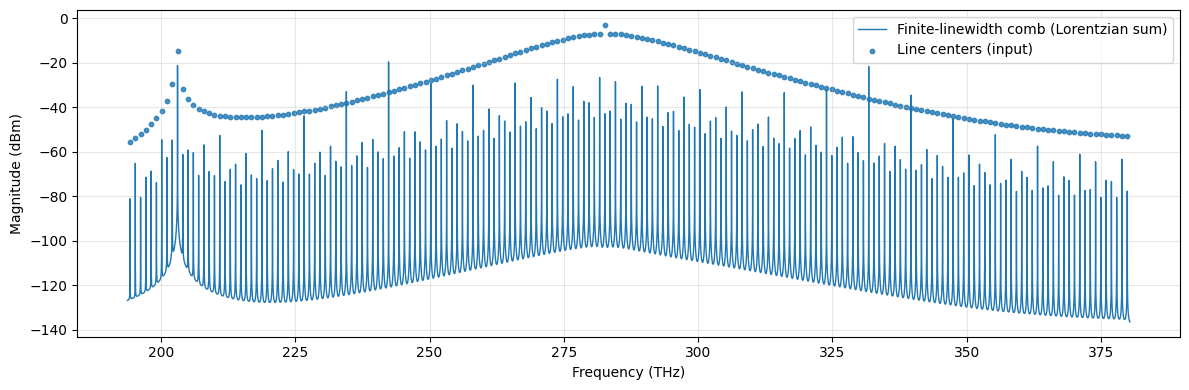

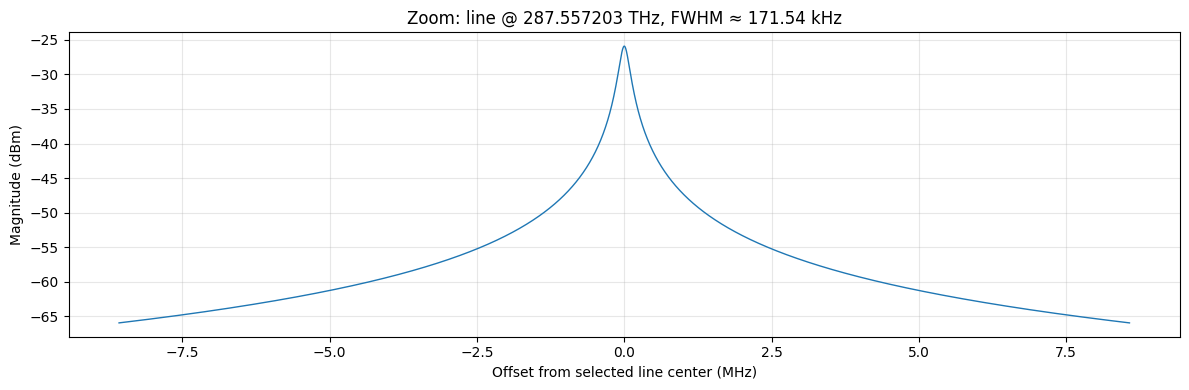

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# def synthesize_comb_dbm(freq_grid_hz, line_freqs_hz, line_powers_dbm, linewidths_hz, noise_floor_dbm=None):
#     """
#     Sum Lorentzian lines. Each line's *integrated* power equals line_powers_dbm (interpreted as total line power).
#     linewidths_hz is FWHM (Hz).
#     """
#     f = np.asarray(freq_grid_hz, float)
#     df = float(np.median(np.diff(f)))  # assumes uniform grid

#     line_freqs_hz = np.asarray(line_freqs_hz, float)
#     linewidths_hz = np.asarray(linewidths_hz, float)
#     linewidths_hz = np.clip(linewidths_hz, 1e-6, None)  # avoid 0/neg

#     # dBm -> W
#     line_powers_w = 1e-3 * 10 ** (np.asarray(line_powers_dbm, float) / 10.0)

#     p_bin_w = np.zeros_like(f)

#     # Vectorized Lorentzian sum: L(f) integrates to 1 over frequency (units 1/Hz)
#     # L(f) = ( (γ/2)/π ) / ( (f-f0)^2 + (γ/2)^2 )
#     g2 = 0.5 * linewidths_hz[:, None]                # (Nlines, 1)
#     f0 = line_freqs_hz[:, None]                      # (Nlines, 1)
#     L = (g2 / np.pi) / ((f[None, :] - f0) ** 2 + g2 ** 2)  # (Nlines, Nf), 1/Hz

#     p_bin_w = (line_powers_w[:, None] * L).sum(axis=0) * df  # W per bin

#     if noise_floor_dbm is not None:
#         p_bin_w += 1e-3 * 10 ** (noise_floor_dbm / 10.0)

#     spec_dbm = 10.0 * np.log10(np.maximum(p_bin_w, 1e-30) / 1e-3)
#     return spec_dbm


# # --- inputs from your notebook ---
# line_freqs_hz = freq_valid
# line_powers_dbm = mag_valid
# linewidths_hz = DeltaNu_each[valid_mask]  # Hz (FWHM)

# # --- frequency grid for plotting ---
# # Wide view (won't resolve kHz–MHz linewidths across a THz-spaced comb, but shows the broadened envelope)
# pad = 0.5 * FSR
# N = 200000
# freq_grid_hz = np.linspace(line_freqs_hz.min() - pad, line_freqs_hz.max() + pad, N)

# spec_dbm = synthesize_comb_dbm(freq_grid_hz, line_freqs_hz, line_powers_dbm, linewidths_hz)

# plt.figure(figsize=(12, 4))
# plt.plot(freq_grid_hz / 1e12, spec_dbm, lw=1, label="Finite-linewidth comb (Lorentzian sum)")
# plt.scatter(line_freqs_hz / 1e12, line_powers_dbm, s=10, alpha=0.8, label="Line centers (input)")
# plt.xlabel("Frequency (THz)")
# plt.ylabel("Magnitude (dBm)")
# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.tight_layout()
# plt.savefig('comb_spectrum.svg',format='svg', dpi = 300)
# plt.show()

# # Optional: zoom around one line to actually see linewidth shape
# k = len(line_freqs_hz) // 2  # pick middle valid line
# f0 = line_freqs_hz[k]
# gamma = linewidths_hz[k]
# span = max(50 * gamma, 5e6)  # ensure visible span (at least 5 MHz)
# f_zoom = np.linspace(f0 - span, f0 + span, 4000)
# spec_zoom_dbm = synthesize_comb_dbm(f_zoom, line_freqs_hz, line_powers_dbm, linewidths_hz)

# plt.figure(figsize=(12, 4))
# plt.plot((f_zoom - f0) / 1e6, spec_zoom_dbm, lw=1)
# plt.xlabel("Offset from selected line center (MHz)")
# plt.ylabel("Magnitude (dBm)")
# plt.title(f"Zoom: line @ {f0/1e12:.6f} THz, FWHM ≈ {gamma/1e3:.2f} kHz")
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

In [128]:
path = '/work3/viswa/results/mrr_sac_cluster_delayed_toptica_pow_ton_un_norm_high_only_detuning_v8/high/new_ctrl_freq/noise_to_shot_5x_delay/10_16__detuning_history.npy'
det_jitter = np.load(path)

path = '/work3/viswa/results/mrr_sac_cluster_delayed_toptica_pow_ton_un_norm_high_only_detuning_v8/high/new_ctrl_freq/noise_to_shot_5x_delay/10_16__p_cav.npy'
power_response = np.load(path)

path = '/work3/viswa/results/mrr_sac_cluster_delayed_toptica_pow_ton_un_norm_high_only_detuning_v8/high/new_ctrl_freq/noise_to_shot_5x_delay/10_16__detuning_theta_sum.npy'
eff_detuning = np.load(path)
thermal_shift = eff_detuning - det_jitter

In [129]:
# %matplotlib widget

/tmp/ipykernel_2438559/796312946.py:4: RuntimeWarning: invalid value encountered in divide
  dd /= np.max(np.abs(dd))


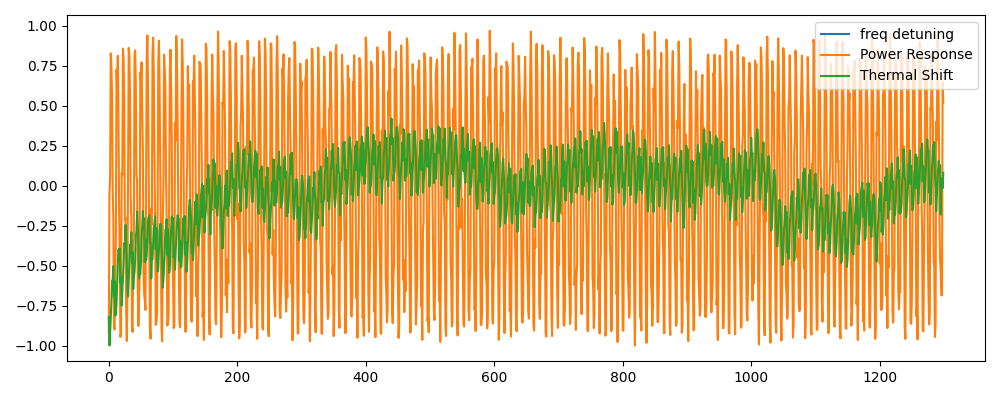

In [140]:
idx = 500
idx_end = 1800
dd = det_jitter[idx:idx_end] - np.median(det_jitter[idx:idx_end])
dd /= np.max(np.abs(dd))

tt = thermal_shift[idx:idx_end] - np.median(thermal_shift[idx:idx_end])
tt /= np.max(np.abs(tt))

pp = power_response[idx:idx_end] - np.median(power_response[idx:idx_end])
pp /= np.max(np.abs(pp))

plt.figure(figsize=(10,4))
plt.plot(dd, label='freq detuning')
plt.plot(pp, label='Power Response')
plt.plot(tt, label='Thermal Shift')
# plt.xlim(100,600)
# plt.ylim(-0.05,0.05)
plt.tight_layout()
plt.legend()
plt.show()

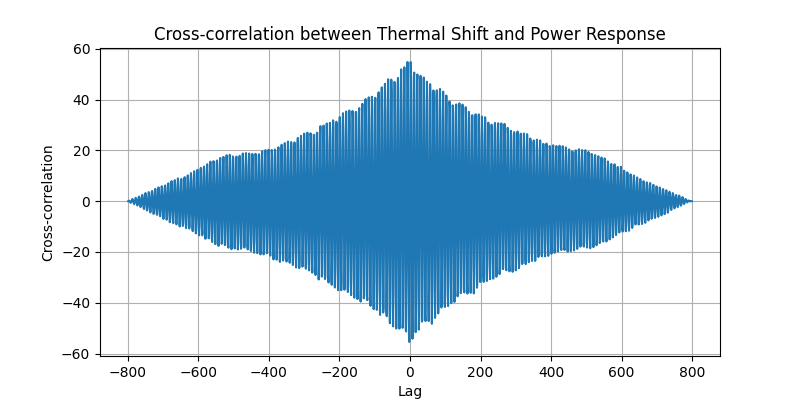

In [137]:
# plot cross-correlation between tt and pp
plt.figure(figsize=(8,4))
correlation = np.correlate(tt[idx:idx_end], pp[idx:idx_end], mode='full')
lags = np.arange(-len(tt[idx:idx_end]) + 1, len(tt[idx:idx_end]))
plt.plot(lags, correlation)
plt.xlabel('Lag')
plt.ylabel('Cross-correlation')
plt.title('Cross-correlation between Thermal Shift and Power Response')
plt.grid()
plt.show()

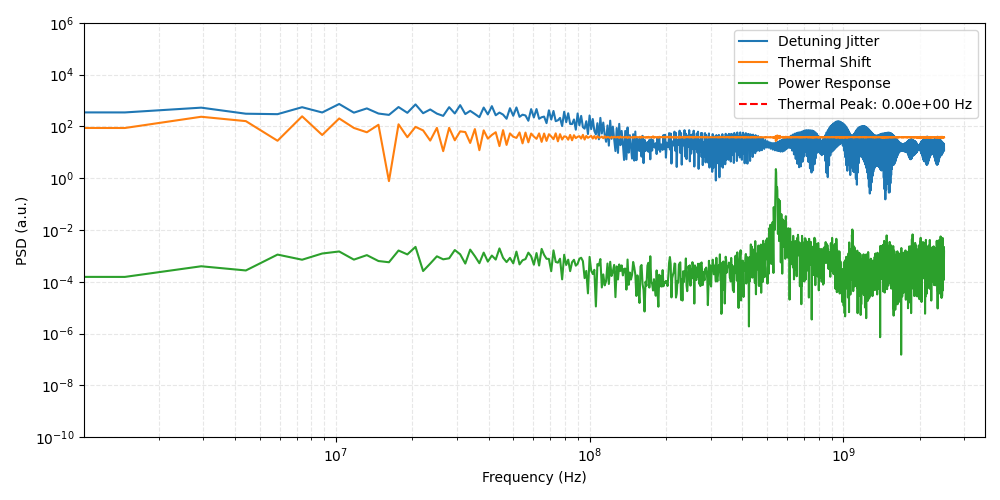

In [145]:
# plot the psd of the three signals from idx =3000 after detrending
idx = 500
det_jitter_fft = detrend(np.fft.fftshift(np.fft.fft(det_jitter[idx:] )), axis=0)
thermal_shift_fft = detrend(np.fft.fftshift(np.fft.fft(thermal_shift[idx:] )), axis=0)
power_response_fft = detrend(np.fft.fftshift(np.fft.fft(power_response[idx:] )), axis=0)

freq = np.fft.fftshift( np.fft.fftfreq(len(det_jitter[idx:]), d=200e-12) )

plt.figure(figsize=(10,5))
plt.loglog(freq, np.abs(det_jitter_fft)**2, label='Detuning Jitter')
plt.loglog(freq, np.abs(thermal_shift_fft)**2, label='Thermal Shift')
plt.loglog(freq, np.abs(power_response_fft)**2, label='Power Response')
# plt.xlim(1e3, 1e9)
plt.ylim(1e-10, 1e6)
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD (a.u.)')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.3)
# find peak of thermal shift psd
peak_idx = np.argmax(np.abs(power_response_fft)**2)
peak_freq = freq[peak_idx]
# plot vertical line at peak frequency
plt.axvline(peak_freq, color='red', linestyle='--', label=f'Thermal Peak: {peak_freq:.2e} Hz')
plt.legend()
plt.tight_layout()
plt.show()